<a href="https://colab.research.google.com/github/padmacharan-123/AAI-LAB/blob/main/Viola_jones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:


import cv2
import numpy as np
import matplotlib.pyplot as plt


In [18]:
import os

In [19]:
print("=" * 60)
print("FACE DETECTION SYSTEM - VIOLA-JONES")
print("=" * 60)


image_path = None

try:
    from google.colab import files
    uploaded = files.upload()

    if uploaded:
        image_path = list(uploaded.keys())[0]

except:
    image_path = input("Enter image path (or press Enter for demo): ").strip()

FACE DETECTION SYSTEM - VIOLA-JONES


Saving a-diverse-group-of-business-people-poses-for-a-professional-team-exuding-confidence-and-professionalism-ai-generative-photo.jpg to a-diverse-group-of-business-people-poses-for-a-professional-team-exuding-confidence-and-professionalism-ai-generative-photo (1).jpg


In [20]:
if image_path and os.path.exists(image_path):
    img = cv2.imread(image_path)
else:
    print("⚠️ Using Demo Image")
    img = np.ones((400, 600, 3), dtype=np.uint8) * 200
    cv2.circle(img, (150, 200), 60, (100, 150, 200), -1)
    cv2.circle(img, (450, 200), 60, (100, 150, 200), -1)
    cv2.circle(img, (300, 350), 60, (100, 150, 200), -1)

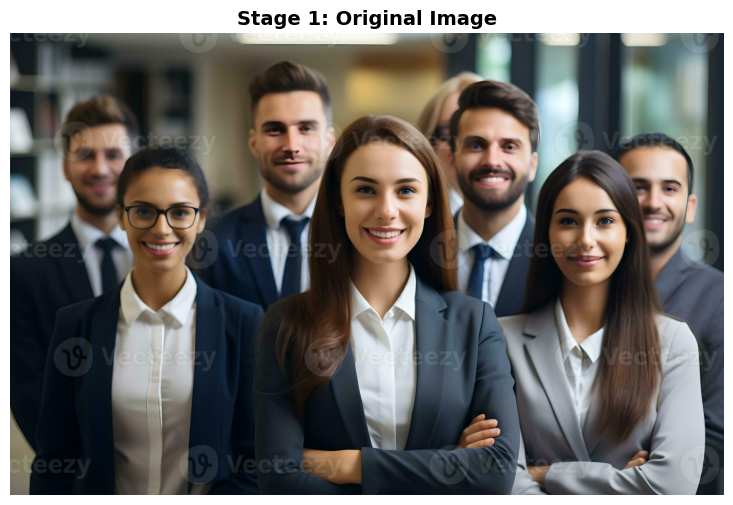

In [21]:
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Stage 1: Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [22]:
print(f" - Height: {img.shape[0]} pixels")
print(f" - Width: {img.shape[1]} pixels")
print(f" - Channels: {img.shape[2]} (BGR)")

 - Height: 1960 pixels
 - Width: 3029 pixels
 - Channels: 3 (BGR)


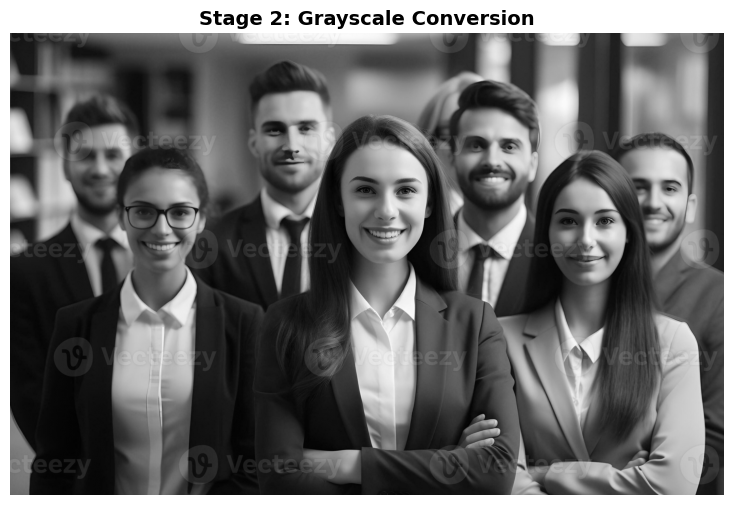

In [23]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 6))
plt.imshow(gray, cmap='gray')
plt.title('Stage 2: Grayscale Conversion', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [24]:
print(f" - Min pixel value: {gray.min()}")
print(f" - Max pixel value: {gray.max()}")
print(f" - Mean: {gray.mean():.2f}")
print(f" - Std Dev: {gray.std():.2f}")

 - Min pixel value: 0
 - Max pixel value: 255
 - Mean: 89.92
 - Std Dev: 64.15


In [25]:
integral = cv2.integral(gray)

integral_normalized = cv2.normalize(
    integral, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)


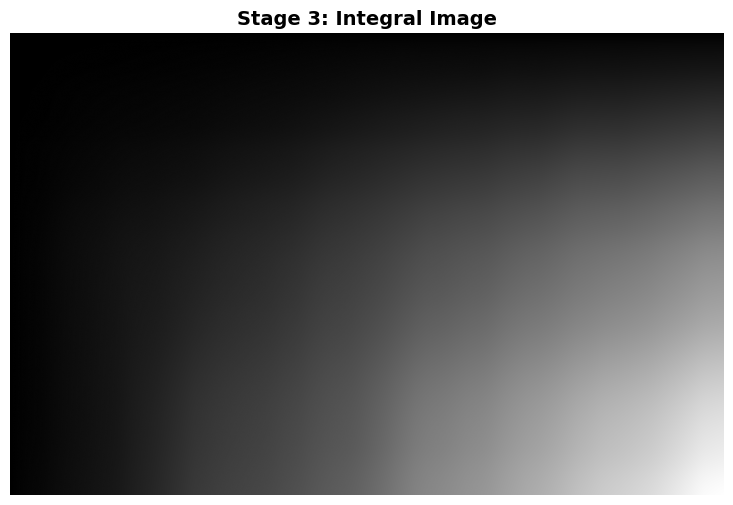

In [26]:
plt.figure(figsize=(10, 6))
plt.imshow(integral_normalized, cmap='gray')
plt.title('Stage 3: Integral Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [27]:
print(f" - Integral shape: {integral.shape}")
print(f" - Total sum: {integral[-1, -1]}")

 - Integral shape: (1961, 3030)
 - Total sum: 533839323


In [28]:
h, w = gray.shape
win_h, win_w = 24, 24

haar_features = gray.copy()
feature_count = 0

for y in range(0, min(h - win_h, 150), 40):
    for x in range(0, min(w - win_w, 150), 40):
        cv2.rectangle(haar_features, (x, y),
                      (x + win_w, y + win_h), 255, 1)
        feature_count += 1

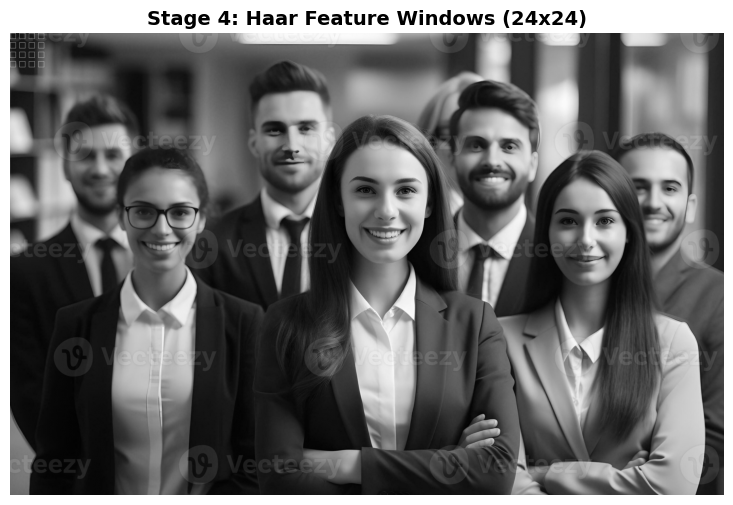

In [29]:
plt.figure(figsize=(10, 6))
plt.imshow(haar_features, cmap='gray')
plt.title('Stage 4: Haar Feature Windows (24x24)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [30]:
print(f" - Window size: {win_w}x{win_h}")
print(f" - Total feature windows: {feature_count}")
print(" - Feature types: 2-rect, 3-rect, 4-rect")

 - Window size: 24x24
 - Total feature windows: 16
 - Feature types: 2-rect, 3-rect, 4-rect


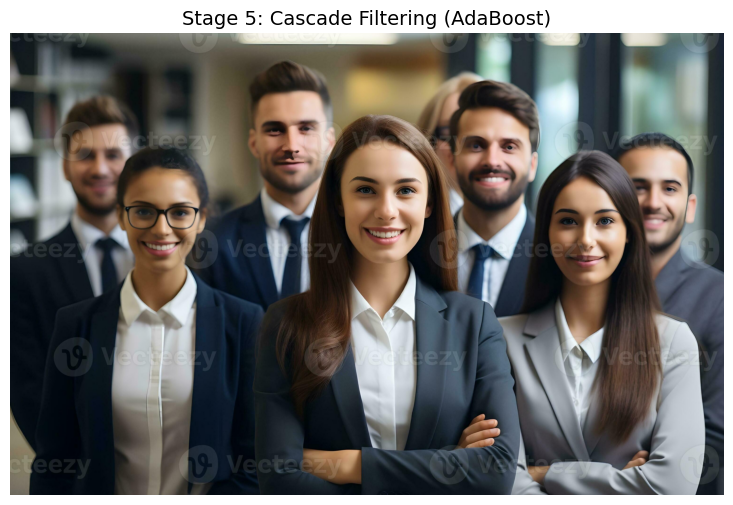

In [31]:
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Stage 5: Cascade Filtering (AdaBoost)', fontsize=14)
plt.axis('off')
plt.show()

In [32]:
print(" - Classifier: haarcascade_frontalface_default.xml")
print(" - Method: AdaBoost Cascade")
print(" - Stages: ~25")

 - Classifier: haarcascade_frontalface_default.xml
 - Method: AdaBoost Cascade
 - Stages: ~25


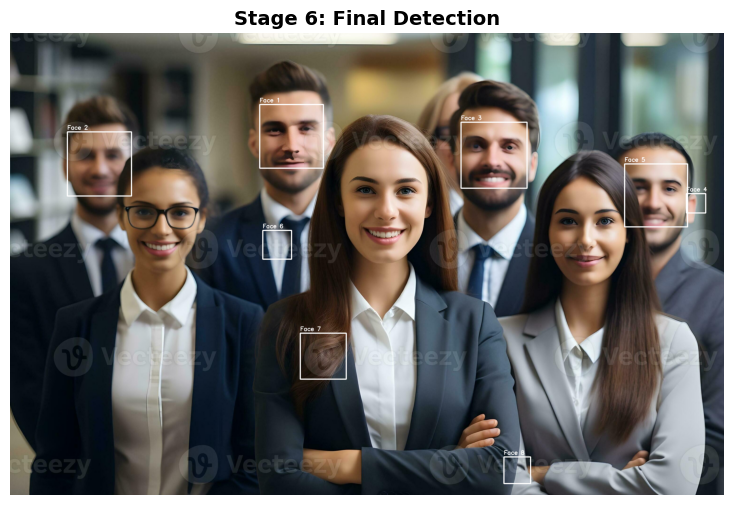

 - Total faces detected: 8


In [33]:
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30),
    maxSize=(300, 300)
)

result_img = img.copy()

for i, (x, y, w, h) in enumerate(faces):
    cv2.rectangle(result_img, (x, y),
                  (x + w, y + h), (255, 255, 255), 3)
    cv2.putText(result_img, f"Face {i+1}",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (255, 255, 255), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title('Stage 6: Final Detection', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

print(f" - Total faces detected: {len(faces)}")